# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
| Group           | 67       |
|-----------------|----------|
| Kazuki Udagawa  | 6169872  |
| Jonah Wilthagen | 6270816  |
| Mauk van 't Hof | 6261000  |
| Satsuki Udagawa | 5747317  |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [3]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        return random.choice(agent.get_valid_actions(maze))

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        state = agent.get_state(maze)
        actions = agent.get_valid_actions(maze)

        # Decide between exploration and exploitation
        explore = np.random.random() < eps

        if explore:
            return random.choice(actions)

        # Compute Q-values for all valid actions
        q_vals = {action: self.q_table.get_q(state, action) for action in actions}

        # Find the maximum Q-value
        max_q = max(q_vals.values())

        # Select all actions that share the maximum Q-value
        best = [a for a, q in q_vals.items() if q == max_q]

        # Break ties randomly
        return random.choice(best)

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        current_state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)
        
        # Compute Boltzmann probabilities
        q_values = [self.q_table.get_q(current_state, action) for action in valid_actions]
        exp_q_values = np.exp(np.array(q_values) / temperature)
        probabilities = exp_q_values / np.sum(exp_q_values)
        
        # Choose an action based on the Boltzmann probabilities
        selected_action = np.random.choice(valid_actions, p=probabilities)
        
        return selected_action


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 2

In [4]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []

for episode in tqdm(range(n_episodes)):
    pass

# Global variable for maximum steps per episode
max_steps_per_episode = 1000

def agent_cycle(agent, exploration_strategy, maze, max_steps):
    rewards_per_episode = []
    steps_taken = 0

    # Continue running episodes until max steps is reached
    while steps_taken < max_steps:

        # Track reward earned in the current episode
        episode_total = 0
        state = agent.get_state(maze)

        # Episode loop: continue until terminal state or per-episode step cap
        episode_steps = 0
        while not state.done and episode_steps < max_steps_per_episode:

            # Select an action using the chosen exploration method
            action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

            # Apply the action and observe the outcome
            next_state, reward, finished = agent.step(action, maze)
            episode_total += reward

            # Placeholder for Q-learning update (not implemented yet)

            # Transition to the next state or reset if episode ends
            if finished:
                agent.reset()
                state = agent.get_state(maze)
            else:
                state = next_state

            # Update counters
            episode_steps += 1
            steps_taken += 1

        # Store the reward accumulated in this episode
        rewards_per_episode.append(episode_total)

    return rewards_per_episode


100%|██████████| 300/300 [00:00<?, ?it/s]


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 3

In [5]:
max_steps_test = 30000
episode_rewards = agent_cycle(agent, exploration_strategy, maze, max_steps_test)

# Confirm that the stopping condition was triggered by the global step cap
if len(episode_rewards) * max_steps_per_episode >= max_steps_test:
    print("Training ran as intended when max steps was reached.")
else:
    print("Warning: The run ended before reaching the maximum steps.")

Training ran as intended when max steps was reached.


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._  
_You may want to directly modify the cycle in Question 2._

#### Question 4

100%|██████████| 10/10 [00:01<00:00,  5.31it/s]


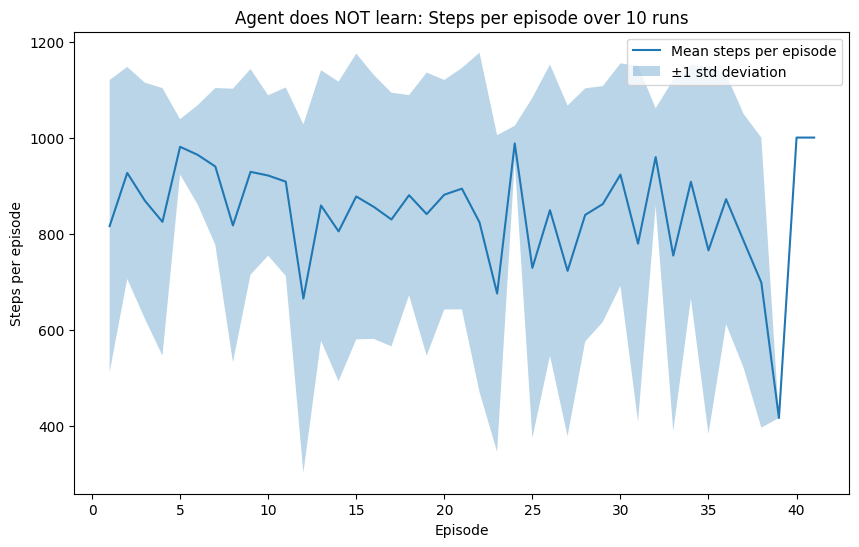

In [13]:
# Run a training run and return steps per episode 
def run_single(agent, exploration_strategy, maze, max_steps_total):
    steps_per_episode = []
    steps_taken = 0

    while steps_taken < max_steps_total:
        state = agent.get_state(maze)
        episode_steps = 0

        while not state.done and episode_steps < max_steps_per_episode:
            action = exploration_strategy.e_greedy(agent, maze, eps=0.1)
            next_state, reward, finished = agent.step(action, maze)

            episode_steps += 1
            steps_taken += 1

            if finished:
                agent.reset()
                break
            else:
                state = next_state

        steps_per_episode.append(episode_steps)

    return steps_per_episode


# Run 10 runs and align episode lengths
def run_multiple(agent, exploration_strategy, maze, n_runs=10, max_steps_total=30000):
    all_runs = []

    for _ in tqdm(range(n_runs)):
        agent.reset()
        steps = run_single(agent, exploration_strategy, maze, max_steps_total)
        all_runs.append(steps)

    # Align runs by padding with NaN
    max_len = max(len(run) for run in all_runs)
    aligned = np.array([run + [np.nan]*(max_len - len(run)) for run in all_runs])

    return aligned


# Run experiments and analyze results
aligned_steps = run_multiple(agent, exploration_strategy, maze)
mean_steps = np.nanmean(aligned_steps, axis=0)
std_steps = np.nanstd(aligned_steps, axis=0)
episodes = np.arange(1, len(mean_steps) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_steps, label="Mean steps per episode")
plt.fill_between(episodes,
                 mean_steps - std_steps,
                 mean_steps + std_steps,
                 alpha=0.3,
                 label="±1 std deviation")

plt.xlabel("Episode")
plt.ylabel("Steps per episode")
plt.title("Agent does NOT learn: Steps per episode over 10 runs")
plt.legend()
plt.show()


<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 5

In [14]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, actions: List[Action], state: State, action: Action, 
              next_state: State, reward: float, done: bool) -> None:

        alpha = self.params.get("lr", 0.7)
        gamma = self.params.get("gamma", 0.9)

        q_old = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            best_future = max(self.q_table.get_q(next_state, a) for a in actions)
            target = reward + gamma * best_future

        q_new = q_old + alpha * (target - q_old)
        self.q_table.set_q(state, action, q_new)

In [16]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
              reward: float, done: bool) -> None:

        alpha = self.params.get("lr", 0.7)
        gamma = self.params.get("gamma", 0.9)

        q_old = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            q_next = self.q_table.get_q(next_state, next_action)
            target = reward + gamma * q_next

        q_new = q_old + alpha * (target - q_old)
        self.q_table.set_q(state, action, q_new)

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

In [18]:
def run_agent(algorithm_class, epsilon, alpha, n_runs=10, n_episodes=200):

    all_runs = []

    for _ in range(n_runs):

        # Fresh environment
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        explorer = ExplorationStrategy(q_table)

        learner = algorithm_class(q_table, {"lr": alpha, "gamma": 0.9})

        steps_per_episode = []

        for _ in range(n_episodes):

            agent.reset()
            state = agent.get_state(maze)
            episode_steps = 0

            # SARSA needs next_action
            action = explorer.e_greedy(agent, maze, epsilon)

            while not state.done:

                next_state, reward, done = agent.step(action, maze)
                episode_steps += 1

                # Q-Learning
                if isinstance(learner, QLearning):
                    learner.learn(
                        actions,
                        state,
                        action,
                        next_state,
                        reward,
                        done
                    )
                    next_action = explorer.e_greedy(agent, maze, epsilon)

                # SARSA
                else:
                    next_action = explorer.e_greedy(agent, maze, epsilon)
                    learner.learn(
                        state,
                        action,
                        next_state,
                        next_action,
                        reward,
                        done
                    )

                state = next_state
                action = next_action

            steps_per_episode.append(episode_steps)

        all_runs.append(steps_per_episode)

    return all_runs


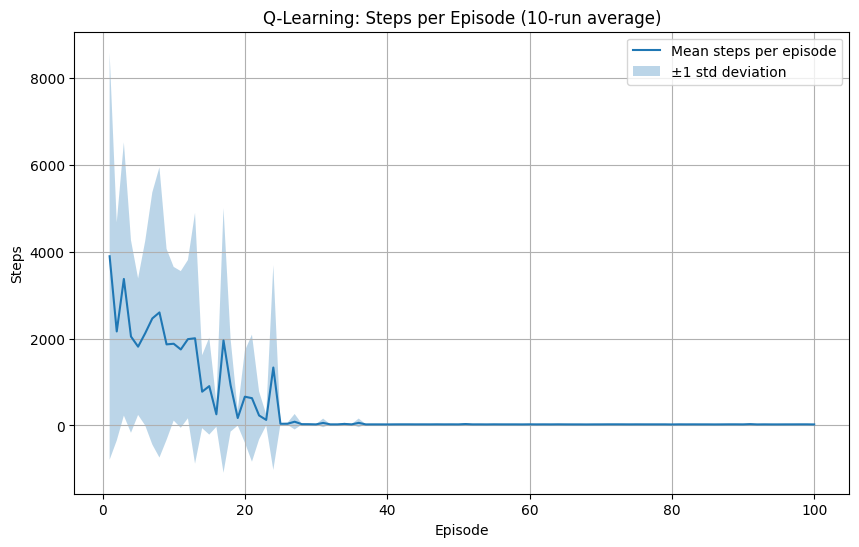

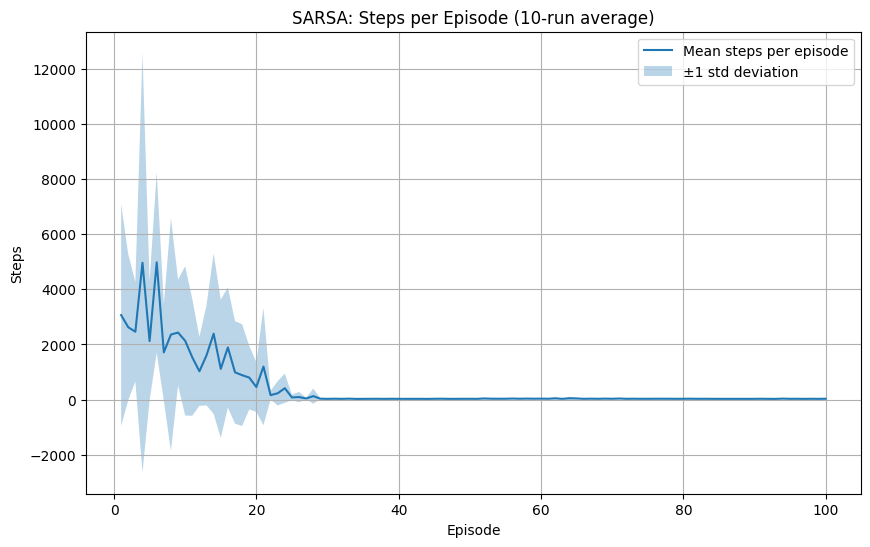

In [22]:
# Hyperparameters
n_runs = 10
n_episodes = 100
epsilon = 0.1
alpha = 0.7

# Run the agent 10 times for each algorithm
runs_q = run_agent(
    algorithm_class=QLearning,
    epsilon=epsilon,
    alpha=alpha,
    n_runs=n_runs,
    n_episodes=n_episodes
)

runs_sarsa = run_agent(
    algorithm_class=SARSA,
    epsilon=epsilon,
    alpha=alpha,
    n_runs=n_runs,
    n_episodes=n_episodes
)

# Plot Q-Learning
max_len_q = max(len(run) for run in runs_q)
aligned_q = np.array([run + [np.nan]*(max_len_q - len(run)) for run in runs_q])

mean_q = np.nanmean(aligned_q, axis=0)
std_q = np.nanstd(aligned_q, axis=0)

episodes_q = np.arange(1, len(mean_q) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes_q, mean_q, label="Mean steps per episode")
plt.fill_between(
    episodes_q,
    mean_q - std_q,
    mean_q + std_q,
    alpha=0.3,
    label="±1 std deviation"
)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Q-Learning: Steps per Episode (10-run average)")
plt.legend()
plt.grid(True)
plt.show()

# Plot SARSA
max_len_s = max(len(run) for run in runs_sarsa)
aligned_s = np.array([run + [np.nan]*(max_len_s - len(run)) for run in runs_sarsa])

mean_s = np.nanmean(aligned_s, axis=0)
std_s = np.nanstd(aligned_s, axis=0)

episodes_s = np.arange(1, len(mean_s) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes_s, mean_s, label="Mean steps per episode")
plt.fill_between(
    episodes_s,
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.3,
    label="±1 std deviation"
)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("SARSA: Steps per Episode (10-run average)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**